Yes. **FastAPI** is a very useful Python framework for a network engineer, but it serves a different purpose from Selenium or Rich.

[FastAPI official documentation](https://fastapi.tiangolo.com/?utm_source=chatgpt.com)

Think of FastAPI as a way to turn your **Python network-automation functions into APIs**.

```text
Network automation function
        ↓
      FastAPI
        ↓
REST API endpoint
        ↓
Other tools/users can call it
        ↓
Router / Switch / Firewall
```

For example, instead of manually running:

```bash
python ping_test.py
```

you could call:

```text
GET /ping/8.8.8.8
```

and receive:

```json
{
    "ip": "8.8.8.8",
    "status": "reachable"
}
```

### 1. Install FastAPI

```bash
pip install fastapi uvicorn
```

Create:

```text
main.py
```

and put:

```python
from fastapi import FastAPI

app = FastAPI()

@app.get("/")
def home():
    return {"message": "Network Automation API"}
```

Start the server:

```bash
uvicorn main:app --reload
```

Then open:

```text
http://127.0.0.1:8000
```

You should receive:

```json
{
    "message": "Network Automation API"
}
```

### 2. Automatic API documentation

One of the nicest FastAPI features is automatically generated interactive documentation.

After starting your server, open:

```text
http://127.0.0.1:8000/docs
```

You get Swagger UI, where you can test your API endpoints directly from the browser.

So your network automation project might expose:

```text
GET  /devices
GET  /device/R1
GET  /ping/8.8.8.8
GET  /interfaces/R1
GET  /bgp/R1
POST /interface/shutdown
POST /interface/no-shutdown
```

This is where FastAPI becomes interesting for network engineers.

### 3. Simple ping API

For example:

```python
import subprocess

from fastapi import FastAPI

app = FastAPI()


@app.get("/ping/{ip}")
def ping_device(ip: str):

    result = subprocess.run(
        ["ping", "-n", "1", ip],
        capture_output=True,
        text=True
    )

    if result.returncode == 0:
        status = "reachable"
    else:
        status = "unreachable"

    return {
        "ip": ip,
        "status": status
    }
```

Run:

```bash
uvicorn main:app --reload
```

Then call:

```text
http://127.0.0.1:8000/ping/8.8.8.8
```

Response:

```json
{
    "ip": "8.8.8.8",
    "status": "reachable"
}
```

Now your ordinary Python ping script has effectively become a small **network API**.

### 4. Multiple-device health API

Suppose you have:

```python
devices = {
    "R1": "10.0.0.1",
    "R2": "10.0.0.2",
    "R3": "10.0.0.3"
}
```

You could create:

```python
@app.get("/devices")
def get_devices():

    return devices
```

Calling:

```text
GET /devices
```

returns:

```json
{
    "R1": "10.0.0.1",
    "R2": "10.0.0.2",
    "R3": "10.0.0.3"
}
```

Or create:

```python
@app.get("/device/{device_name}")
def get_device(device_name: str):

    return {
        "device": device_name,
        "ip": devices.get(device_name)
    }
```

Then:

```text
GET /device/R1
```

could return:

```json
{
    "device": "R1",
    "ip": "10.0.0.1"
}
```

### 5. FastAPI + Netmiko

This is where it gets much more useful.

Imagine you already have a Netmiko function:

```python
from netmiko import ConnectHandler

def get_interfaces(router):

    connection = ConnectHandler(**router)

    output = connection.send_command(
        "show ip interface brief"
    )

    connection.disconnect()

    return output
```

FastAPI can expose that function:

```python
@app.get("/interfaces/{router_name}")
def interfaces(router_name: str):

    output = get_interfaces(devices[router_name])

    return {
        "router": router_name,
        "interfaces": output
    }
```

Now:

```text
GET /interfaces/R1
```

could internally do:

```text
API request
   ↓
FastAPI
   ↓
Python
   ↓
Netmiko
   ↓
SSH
   ↓
Cisco Router
   ↓
show ip interface brief
   ↓
FastAPI JSON response
```

### 6. BGP health API

Imagine you build:

```text
GET /bgp/R1
```

and receive:

```json
{
    "device": "R1",
    "neighbors": [
        {
            "neighbor": "10.1.1.1",
            "state": "Established"
        },
        {
            "neighbor": "10.1.1.2",
            "state": "Idle"
        }
    ]
}
```

Your monitoring system can immediately detect:

```text
10.1.1.2 → BGP DOWN
```

The same concept can be used for:

```text
/bgp
/isis
/ospf
/interfaces
/lacp
/bfd
/routes
/cpu
/memory
/ping
/traceroute
```

### 7. GET vs POST

You'll see these constantly when learning FastAPI.

**GET** normally retrieves information:

```text
GET /devices
GET /bgp/R1
GET /interfaces/R1
GET /routes/R1
```

**POST** normally sends data or requests an action:

```text
POST /devices
POST /tests
POST /interface/shutdown
```

For example:

```python
from pydantic import BaseModel

class PingRequest(BaseModel):
    ip: str


@app.post("/ping")
def ping(request: PingRequest):

    return {
        "target": request.ip,
        "status": "testing"
    }
```

You send:

```json
{
    "ip": "8.8.8.8"
}
```

FastAPI validates that input using Pydantic.

### 8. Network automation architecture

You could eventually build something much more powerful:

```text
                    User
                      |
                      ↓
               Web Dashboard
                      |
                      ↓
                   FastAPI
                      |
        +-------------+-------------+
        |             |             |
        ↓             ↓             ↓
     Netmiko        PyATS        Requests
        |             |             |
        ↓             ↓             ↓
      SSH          Testing          REST
        |             |             |
        +-------------+-------------+
                      |
          +-----------+-----------+
          |           |           |
          ↓           ↓           ↓
        Cisco       Juniper     Arista
```

For example, your dashboard could have:

```text
NETWORK LAB HEALTH

Device    Ping    BGP          IS-IS    Interfaces
--------------------------------------------------
R1        UP      Established  UP       48/48
R2        UP      Established  UP       47/48
R3        UP      IDLE         UP       48/48
R4        DOWN    N/A          N/A      N/A
```

FastAPI provides the backend API while another application provides the frontend.

### 9. FastAPI + the libraries you're learning

These libraries actually complement each other:

```text
                    Python
                      |
     +----------------+----------------+
     |                |                |
   Rich            Selenium         FastAPI
     |                |                |
 Terminal          Browser            API
 output           automation         backend
```

And add networking libraries:

```text
                    FastAPI
                       |
       +---------------+---------------+
       |               |               |
    Netmiko           PyATS          Requests
       |               |               |
      SSH          Validation          API
       |               |               |
       +---------------+---------------+
                       |
                 Network Devices
```

### 10. Where FastAPI is especially useful for a network engineer

| Project | FastAPI use |
|---|---|
| Ping monitor | `/ping/{ip}` |
| Device inventory | `/devices` |
| Interface monitor | `/interfaces/{device}` |
| BGP monitor | `/bgp/{device}` |
| IS-IS monitor | `/isis/{device}` |
| LAG checker | `/lags/{device}` |
| Route lookup | `/route/{prefix}` |
| Configuration validation | `/validate/{device}` |
| Network test automation | `/tests/run` |
| Lab automation | `/lab/status` |
| Network dashboard | Backend API |
| Multi-vendor automation | Common REST interface |

A strong practical progression for network automation is therefore:

**Python → Requests → Netmiko → TextFSM/Genie → Rich → FastAPI → PyATS → Ansible**

Once you know these pieces, you can build a real **multi-vendor network health API** where FastAPI receives a request, Netmiko connects to Cisco/Juniper/Arista devices, Genie/TextFSM parses command output, and the API returns structured JSON.

In [2]:
!pip install fastapi uvicorn

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://packagefeedproxy.microsoft.io/pypi/simple/

   ---------------------------------------- 0/3 [uvicorn]
   ---------------------------------------- 0/3 [uvicorn]
   ------------- -------------------------- 1/3 [starlette]
   -------------------------- ------------- 2/3 [fastapi]
   -------------------------- ------------- 2/3 [fastapi]
   -------------------------- ------------- 2/3 [fastapi]
   ---------------------------------------- 3/3 [fastapi]



In [5]:
!uvicorn main:app --reload

^C


Command to see below in browser is:

http://127.0.0.1:8000

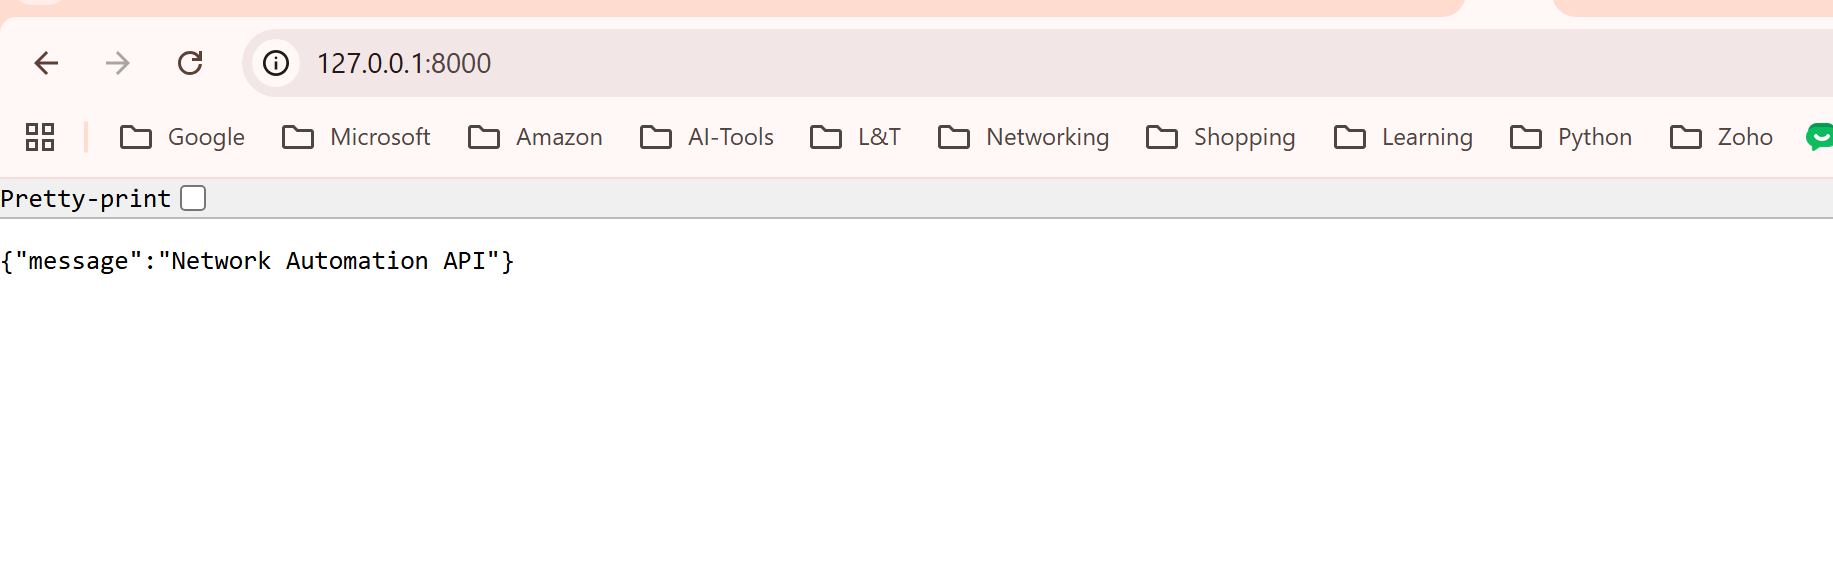




run the command in the broswer:

http://127.0.0.1:8000/docs


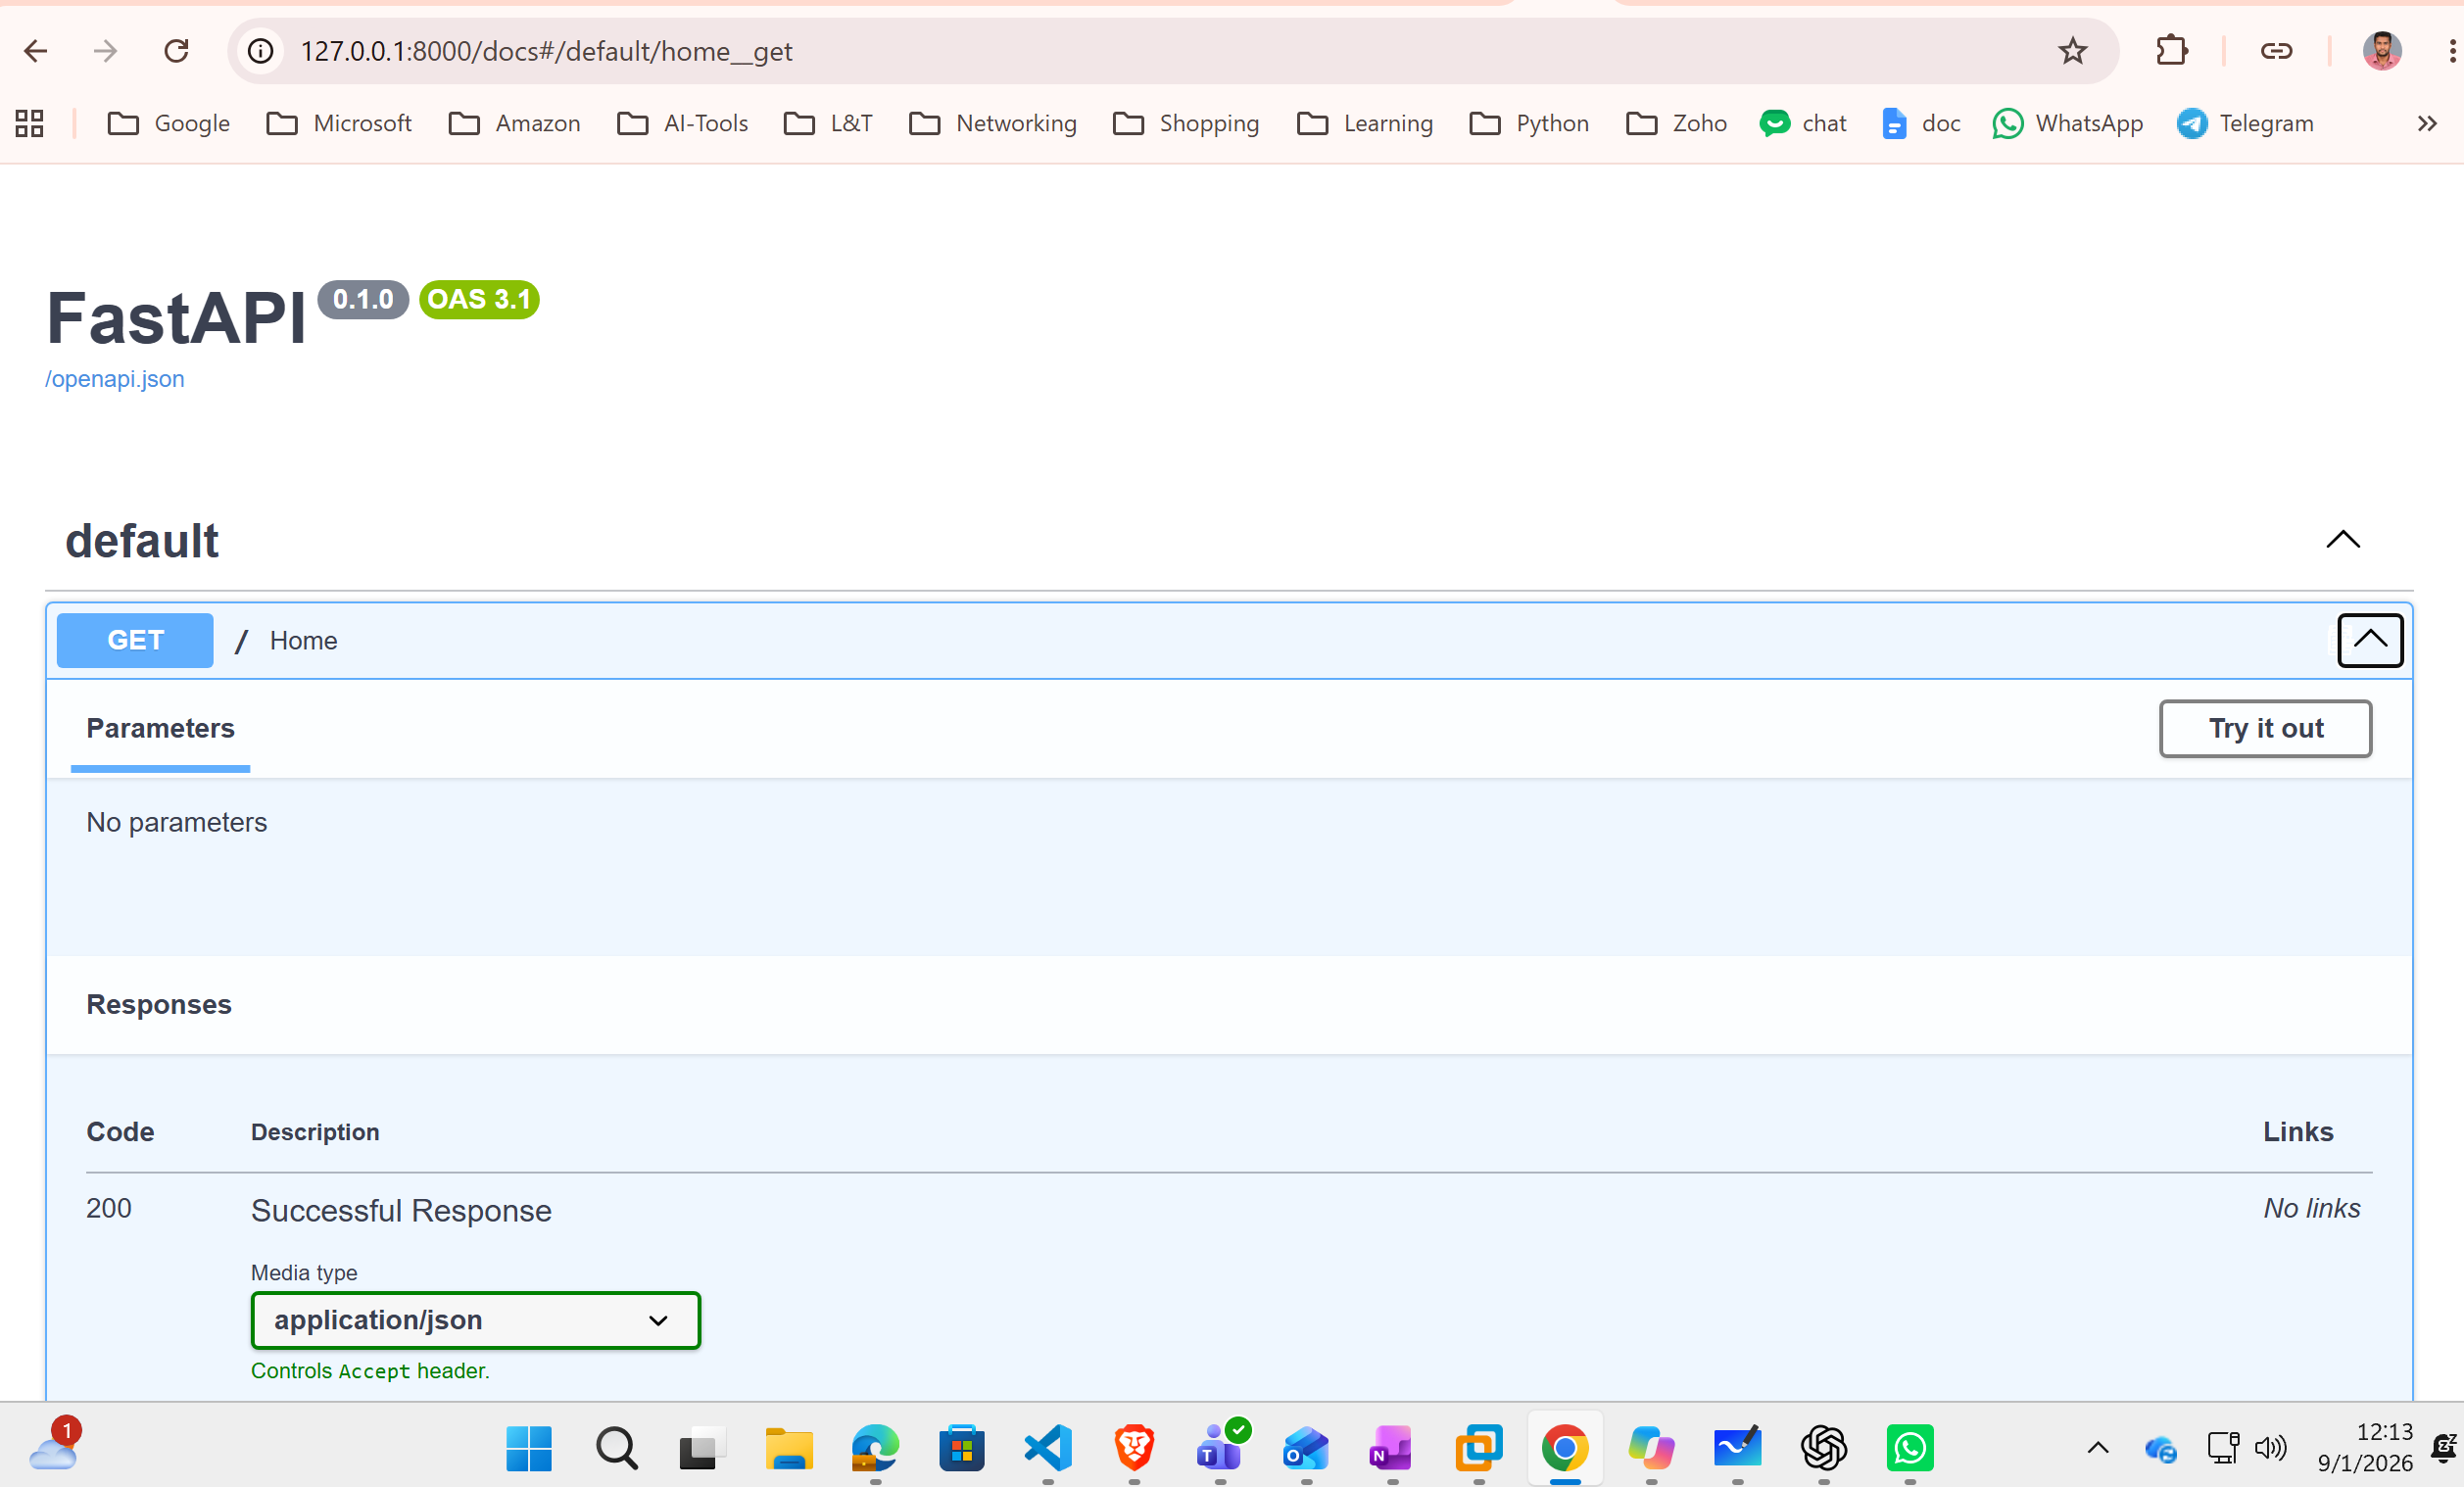


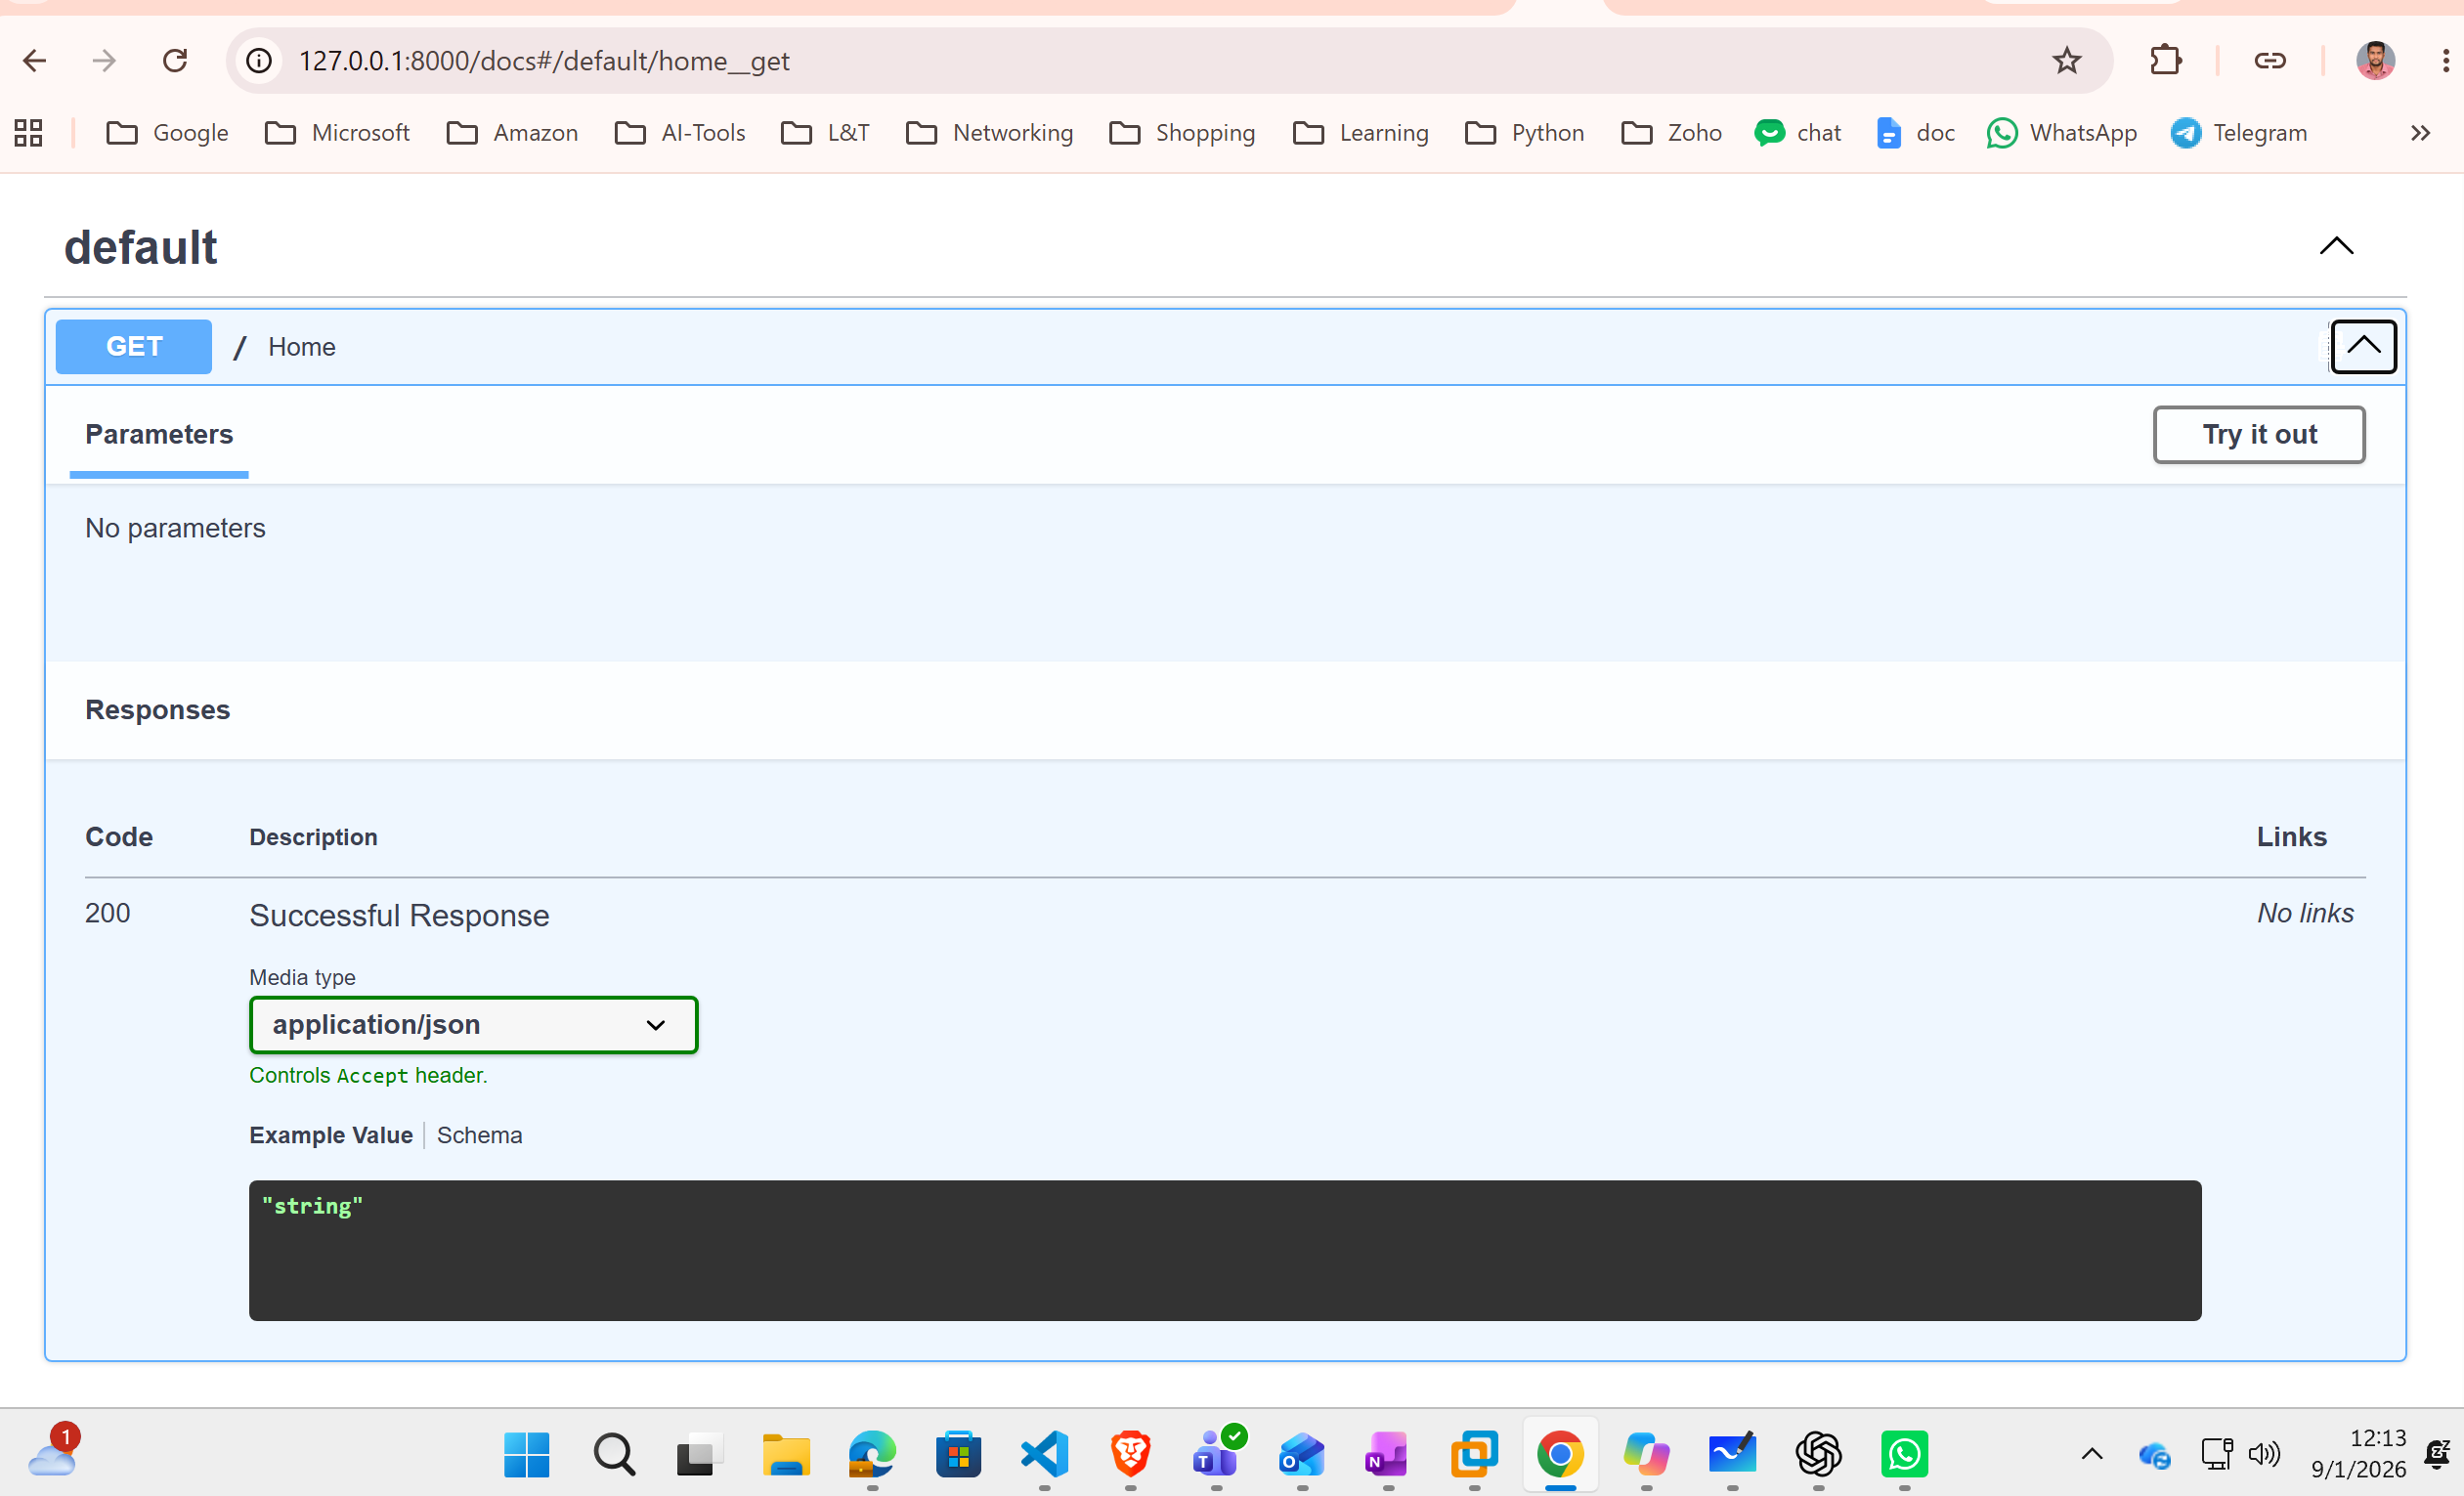

In [6]:
!uvicorn ping:app --reload

^C


http://127.0.0.1:8000/ping/8.8.8.8


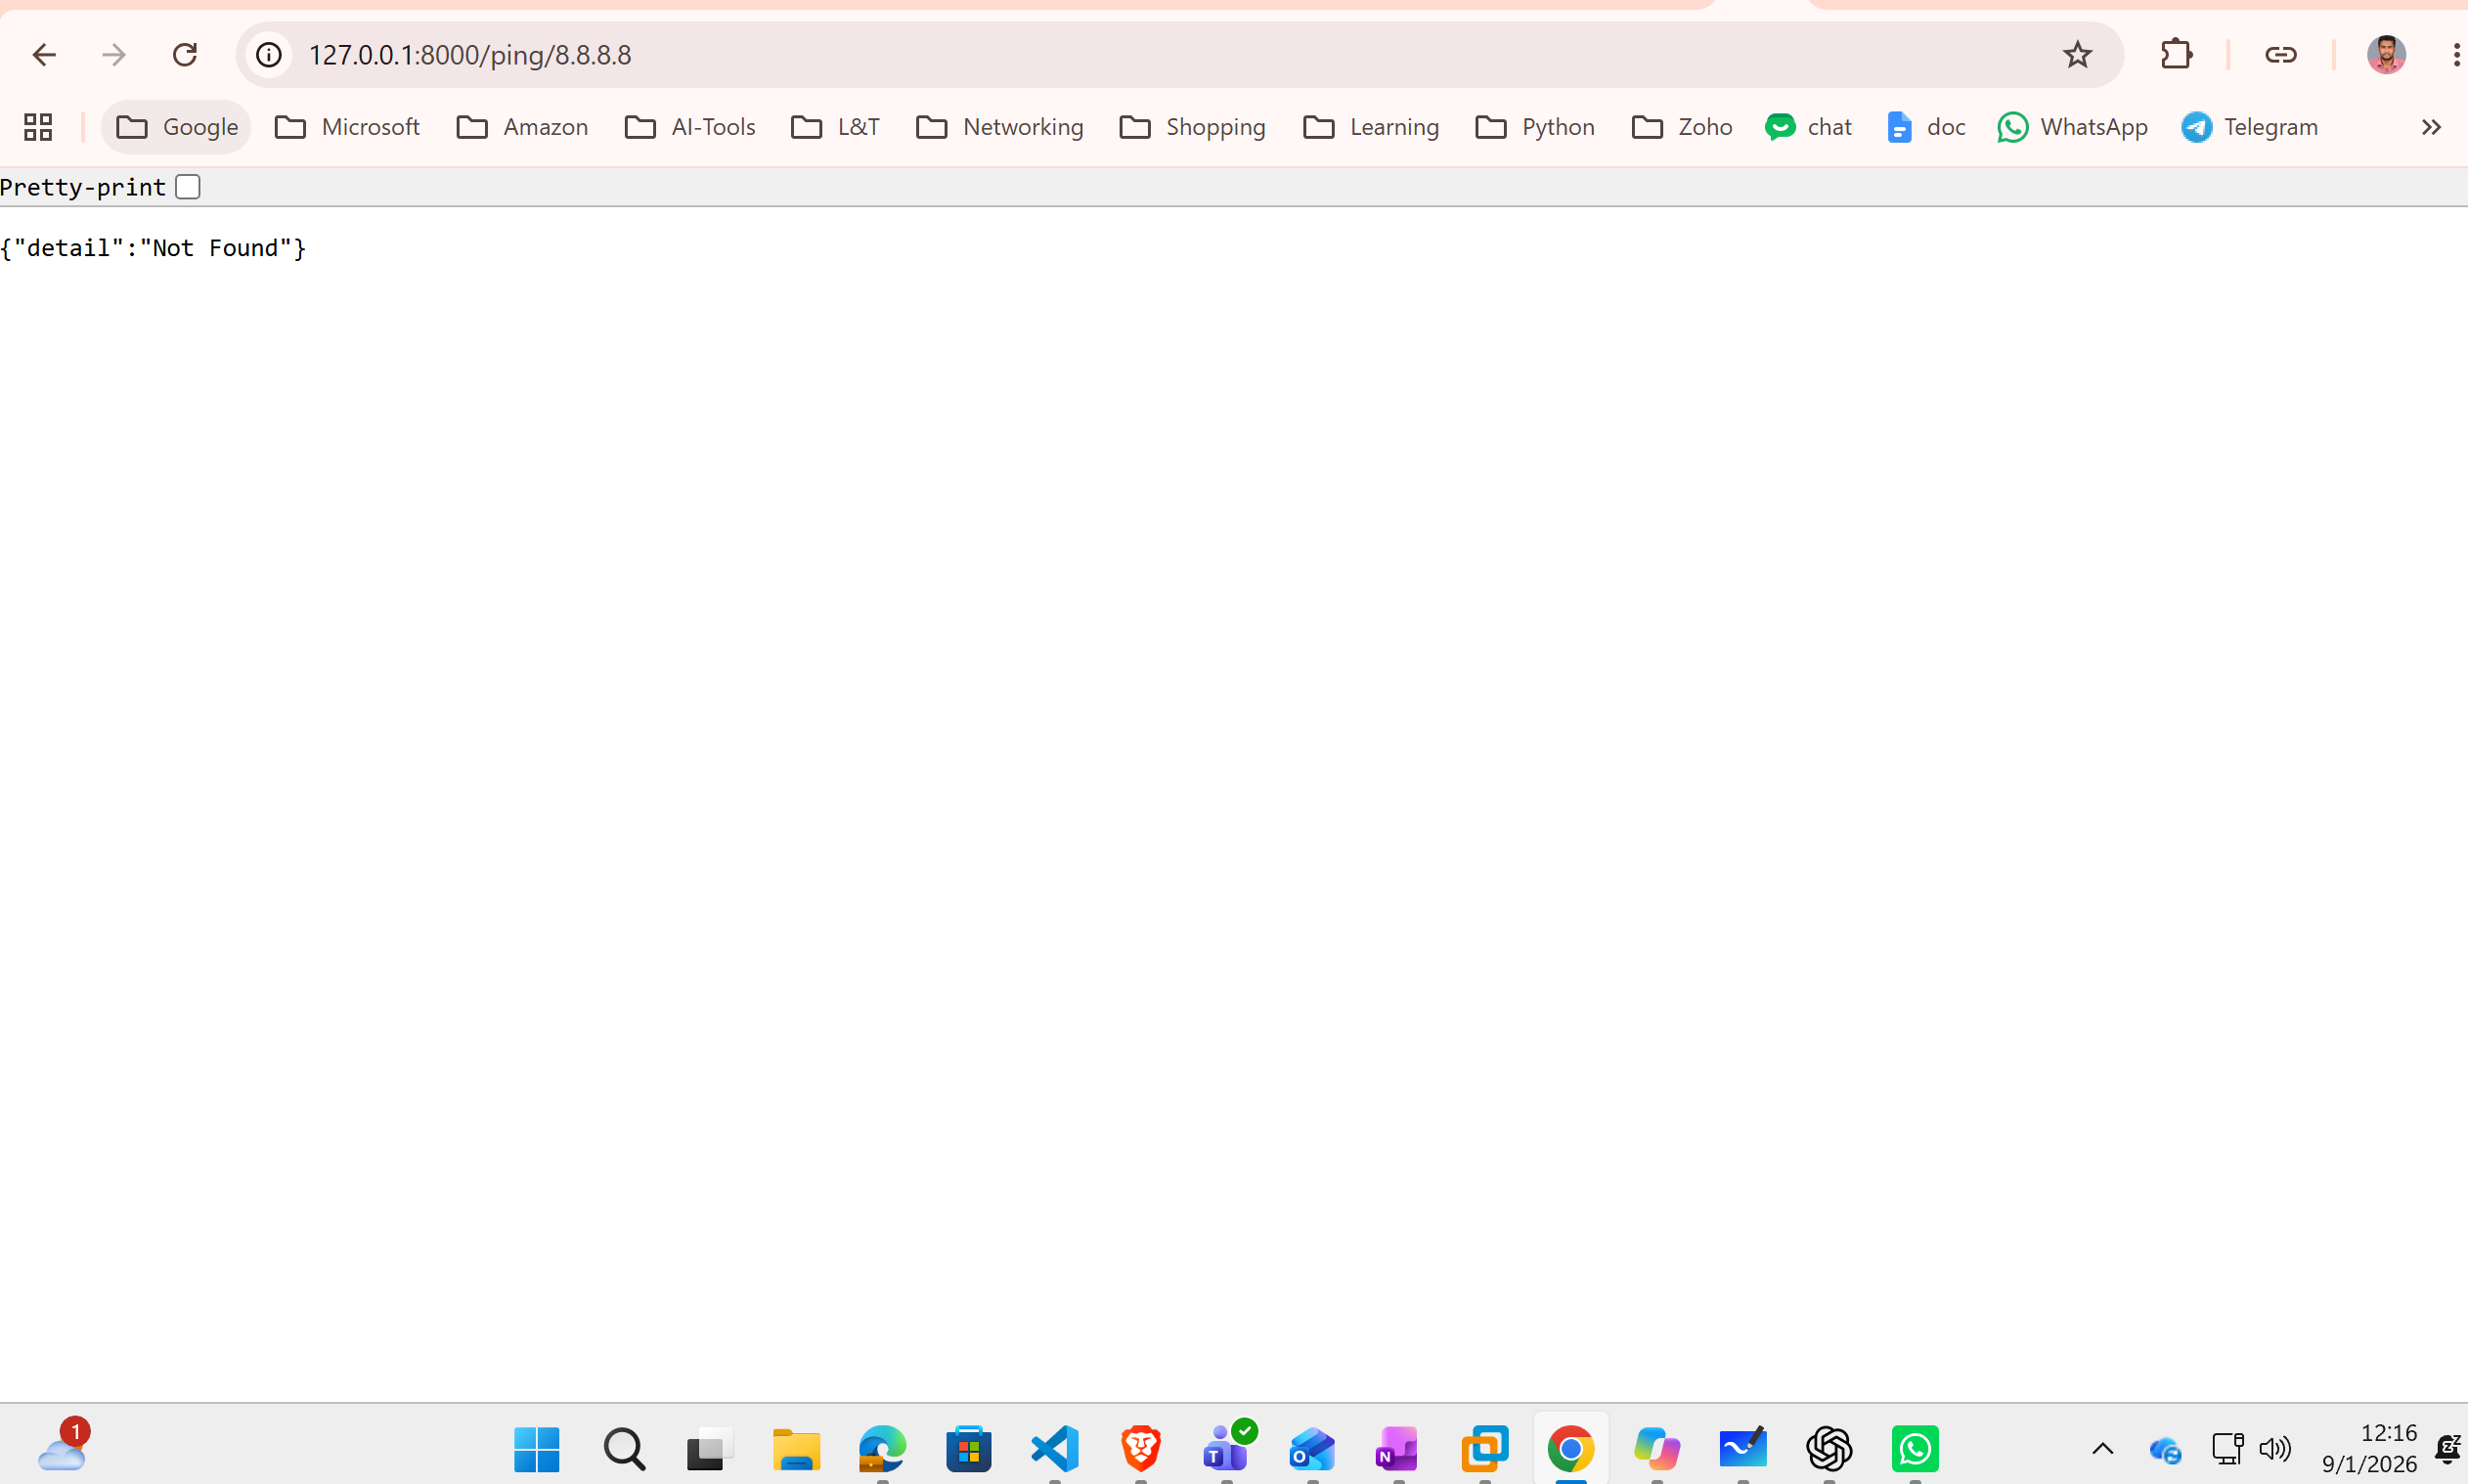

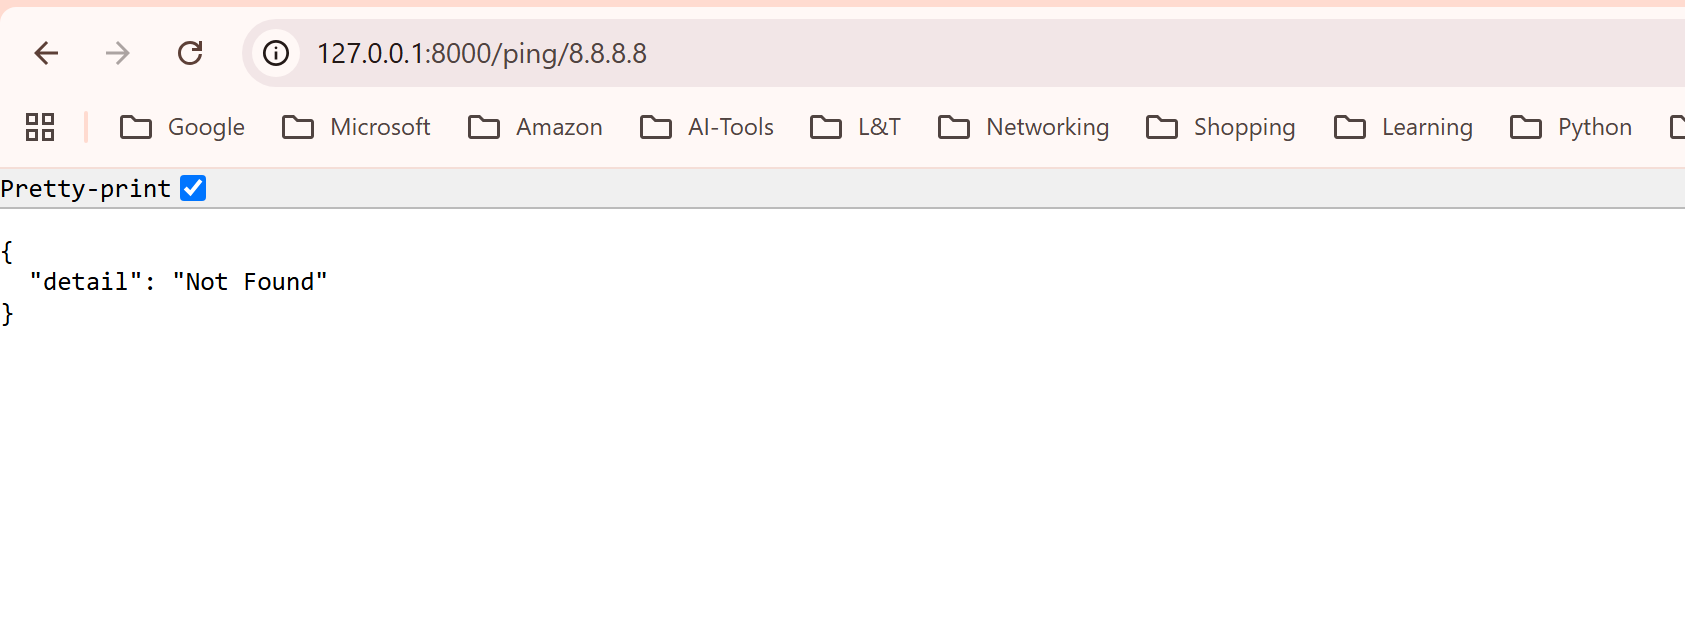

Yes. This is a very good FastAPI project for a network engineer.

A **TCP ping** is different from ICMP `ping`. Instead of sending an ICMP Echo Request, we'll try to establish a **TCP connection to a specific port**.

For example:

```text
TCP Ping → 8.8.8.8:443

Your PC
   │
   │ TCP SYN
   ▼
8.8.8.8:443
   │
   │ SYN-ACK
   ▼
TCP port reachable
```

## 1. Create `main.py`

Put this in your `main.py`:

```python
from fastapi import FastAPI
import socket
import time

app = FastAPI()


@app.get("/")
def home():
    return {
        "message": "Network TCP Testing API"
    }


@app.get("/tcp-ping/{host}/{port}")
def tcp_ping(host: str, port: int):

    start_time = time.time()

    try:
        connection = socket.create_connection(
            (host, port),
            timeout=3
        )

        connection.close()

        end_time = time.time()

        response_time = round(
            (end_time - start_time) * 1000,
            2
        )

        return {
            "host": host,
            "port": port,
            "status": "reachable",
            "response_time_ms": response_time
        }

    except socket.timeout:

        return {
            "host": host,
            "port": port,
            "status": "timeout"
        }

    except ConnectionRefusedError:

        return {
            "host": host,
            "port": port,
            "status": "connection refused"
        }

    except Exception as error:

        return {
            "host": host,
            "port": port,
            "status": "failed",
            "error": str(error)
        }
```

## 2. Start FastAPI

Don't run this inside a normal Python/Jupyter cell.

Open the **VS Code Terminal** and run:

```bash
python -m uvicorn main:app --reload
```

You should get something similar to:

```text
INFO:     Uvicorn running on http://127.0.0.1:8000
INFO:     Application startup complete.
```

Keep this terminal running.

## 3. Test using Swagger

Now open:

```text
http://127.0.0.1:8000/docs
```

You'll see your FastAPI Swagger interface.

You should have:

```text
GET
/tcp-ping/{host}/{port}
```

Click it → **Try it out**.

Enter:

```text
host = 8.8.8.8
port = 443
```

Then click **Execute**.

You might receive:

```json
{
    "host": "8.8.8.8",
    "port": 443,
    "status": "reachable",
    "response_time_ms": 12.84
}
```

That means a TCP connection to:

```text
8.8.8.8:443
```

succeeded.

## 4. Test directly from your browser

You don't even need Swagger.

Enter:

```text
http://127.0.0.1:8000/tcp-ping/8.8.8.8/443
```

Your browser calls:

```text
GET /tcp-ping/8.8.8.8/443
```

FastAPI then runs:

```python
socket.create_connection(
    ("8.8.8.8", 443),
    timeout=3
)
```

The complete process is:

```text
Browser
   │
   │ GET /tcp-ping/8.8.8.8/443
   ▼
FastAPI
   │
   ▼
Python socket
   │
   │ TCP SYN
   ▼
8.8.8.8:443
   │
   │ SYN-ACK
   ▼
TCP connection successful
   │
   ▼
FastAPI
   │
   ▼
JSON response
```

## 5. Try different ports

Now you can use it for network troubleshooting.

For HTTPS:

```text
/tcp-ping/google.com/443
```

For HTTP:

```text
/tcp-ping/google.com/80
```

For SSH on a device you administer:

```text
/tcp-ping/192.168.1.10/22
```

For your EVE-NG server:

```text
/tcp-ping/192.168.32.128/443
```

That last one can be particularly useful because it answers:

> "Can my machine establish a TCP connection to the EVE-NG HTTPS service?"

rather than simply:

> "Does EVE-NG answer ICMP ping?"

## 6. Test a failure

Testing failures is important.

For example, if a host is reachable but nothing is listening on the requested port, you may receive:

```json
{
    "host": "192.168.1.10",
    "port": 9999,
    "status": "connection refused"
}
```

There is an important networking distinction here.

**Reachable:**

```text
Client                 Server
  │                       │
  │ ------- SYN --------> │
  │ <---- SYN-ACK ------- │
  │                       │
  │ TCP connection works  │
```

**Connection refused:**

```text
Client                 Server
  │                       │
  │ ------- SYN --------> │
  │ <------ RST --------- │
  │                       │
  │ Host reachable        │
  │ Port not accepting    │
```

**Timeout:**

```text
Client
  │
  │ ------- SYN -------->  ???
  │
  │       no response
  │
  │ ------- SYN -------->  ???
  │
  │       no response
  │
  ▼
TIMEOUT
```

A timeout could indicate a firewall dropping traffic, routing problem, unreachable destination, or another network-path issue.

## 7. Make the API cleaner

Once you understand the first version, I prefer using query parameters:

```python
@app.get("/tcp-ping")
def tcp_ping(host: str, port: int = 443):
    ...
```

Then your request becomes:

```text
/tcp-ping?host=8.8.8.8&port=443
```

FastAPI automatically understands:

```text
host = 8.8.8.8
port = 443
```

And because we gave:

```python
port: int = 443
```

443 becomes the default.

So:

```text
/tcp-ping?host=google.com
```

automatically tests port 443.

## Why this is useful for you as a network engineer

You can eventually expand this into one troubleshooting API:

```text
Network Troubleshooting API

GET /ping
       ↓
ICMP reachability

GET /tcp-ping
       ↓
TCP port reachability

GET /dns
       ↓
DNS resolution

GET /http
       ↓
HTTP test

GET /https
       ↓
HTTPS test

GET /bgp
       ↓
BGP health

GET /interfaces
       ↓
Interface health

GET /route
       ↓
Route lookup
```

That would be a useful next FastAPI project: build **one Network Troubleshooting API** that performs **ICMP ping + TCP ping + DNS lookup + HTTP/HTTPS test + traceroute**, returning all the results as structured JSON.

In [2]:
!uvicorn tcp_ping:app --reload

^C


http://127.0.0.1:8000/tcp-ping/8.8.8.8/443



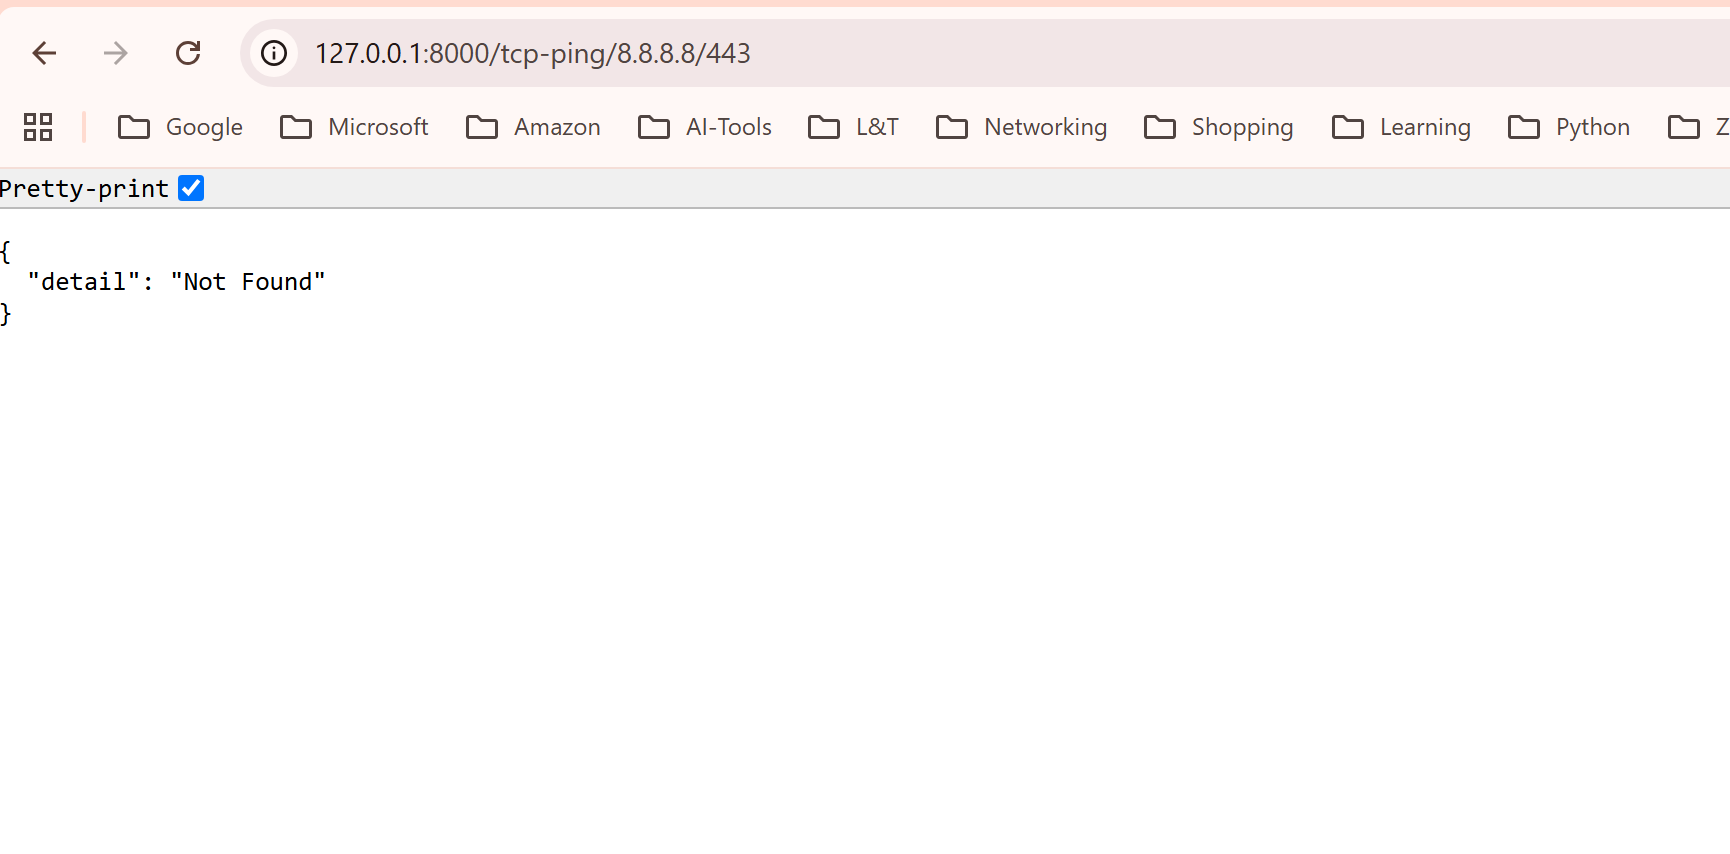

The important part of your error is:

```text
ERROR: Error loading ASGI app. Could not import module "tcp_ping".
```

Your command is:

```powershell
python -m uvicorn tcp_ping:app --reload
```

That means Uvicorn is looking for a Python file named:

```text
tcp_ping.py
```

in your current directory:

```text
C:\Users\v-yaalam\Downloads\vscode_Dell_17
```

and inside that file it expects:

```python
app = FastAPI()
```

Most likely, your `tcp_ping.py` file is inside another folder, or the filename is different.

Try this first in the terminal:

```powershell
dir
```

Check whether you see:

```text
tcp_ping.py
```

If you do not see it, move into the folder where the file exists. For example, if your structure is:

```text
vscode_Dell_17
│
└── Libraries_learning
    └── FastAPI
        └── tcp_ping.py
```

then run:

```powershell
cd Libraries_learning\FastAPI
```

Then:

```powershell
python -m uvicorn tcp_ping:app --reload
```

Your terminal should now be in:

```text
C:\Users\v-yaalam\Downloads\vscode_Dell_17\Libraries_learning\FastAPI
```

Alternatively, if you want to remain in the parent directory, you can use the full Python module path:

```powershell
python -m uvicorn Libraries_learning.FastAPI.tcp_ping:app --reload
```

provided those directories can be imported as Python packages.

Also verify that `tcp_ping.py` actually contains:

```python
from fastapi import FastAPI
import socket
import time

app = FastAPI()


@app.get("/")
def home():
    return {
        "message": "TCP Ping API is running"
    }


@app.get("/tcp-ping/{host}/{port}")
def tcp_ping(host: str, port: int):

    start = time.time()

    try:
        connection = socket.create_connection(
            (host, port),
            timeout=3
        )

        connection.close()

        latency = round(
            (time.time() - start) * 1000,
            2
        )

        return {
            "host": host,
            "port": port,
            "status": "reachable",
            "latency_ms": latency
        }

    except socket.timeout:
        return {
            "host": host,
            "port": port,
            "status": "timeout"
        }

    except ConnectionRefusedError:
        return {
            "host": host,
            "port": port,
            "status": "connection refused"
        }

    except Exception as error:
        return {
            "host": host,
            "port": port,
            "status": "failed",
            "error": str(error)
        }
```

Then run:

```powershell
python -m uvicorn tcp_ping:app --reload
```

If successful, you should see:

```text
INFO: Uvicorn running on http://127.0.0.1:8000
INFO: Application startup complete.
```

Then test:

```text
http://127.0.0.1:8000/docs
```

Or directly:

```text
http://127.0.0.1:8000/tcp-ping/8.8.8.8/443
```

The key rule to remember is:

```text
python -m uvicorn tcp_ping:app --reload
                         │       │
                         │       └── app = FastAPI()
                         │
                         └── tcp_ping.py
```

So the filename and the variable name must match exactly.